## **Imports**

In [6]:
import pandas as pd 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, accuracy_score,\
                         precision_score, confusion_matrix,f1_score,recall_score
from imblearn.over_sampling import ADASYN, SMOTE
import matplotlib.pyplot as plt 
import seaborn as sns
from torch.utils.data import Dataset
torch.manual_seed(42)
np.random.seed(42)

gpu_available = torch.cuda.is_available()
print(f"Is GPU available? {gpu_available}")

Is GPU available? True


## **1.1 EDA**

In [7]:
df_train = pd.read_csv(r".\Data\train.csv")
df_test = pd.read_csv(r".\Data\test_without_labels.csv")
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        7000 non-null   int64  
 1   CustomerId       7000 non-null   int64  
 2   Surname          7000 non-null   object 
 3   CreditScore      7000 non-null   int64  
 4   Geography        7000 non-null   object 
 5   Gender           7000 non-null   object 
 6   Age              7000 non-null   int64  
 7   Tenure           7000 non-null   int64  
 8   Balance          7000 non-null   float64
 9   NumOfProducts    7000 non-null   int64  
 10  HasCrCard        7000 non-null   int64  
 11  IsActiveMember   7000 non-null   int64  
 12  EstimatedSalary  7000 non-null   float64
 13  Exited           7000 non-null   int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 765.8+ KB


In [8]:
df_train.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [9]:
df_train.shape

(7000, 14)

In [10]:
df_train.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,3888,15769110,Stehle,653,France,Female,46,5,0.00,2,1,0,49707.85,0
1,6618,15700826,Ko,678,Germany,Female,54,1,123699.28,2,0,1,105221.76,0
2,6622,15710365,Thomson,646,France,Male,50,0,104129.24,2,1,0,181794.86,1
3,6627,15619932,Lombardi,847,France,Male,66,7,123760.68,1,0,1,53157.16,0
4,8353,15641413,Crawford,587,Germany,Female,49,7,155393.98,2,1,0,13308.20,1


In [11]:
dcols = ['RowNumber','CustomerId','Surname']
df_train = df_train.drop(dcols,axis=1)
df_test = df_test.drop(dcols,axis=1)
df_train.shape

(7000, 11)

In [12]:
df_test.shape

(3000, 10)

In [13]:
df_train.describe(include='all')

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,7000.000000,7000,7000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
unique,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,3731,3855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,656.569143,NaN,NaN,38.354714,4.899714,63472.755893,1.593286,0.708286,0.604429,99713.609907,0.181000
std,95.271157,NaN,NaN,10.251685,2.883349,62086.696345,0.567376,0.454584,0.489008,57642.616664,0.385046
min,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,595.000000,NaN,NaN,31.000000,2.000000,0.000000,1.000000,0.000000,0.000000,49870.507500,0.000000
50%,657.000000,NaN,NaN,37.000000,5.000000,75439.280000,2.000000,1.000000,1.000000,99796.845000,0.000000
75%,722.000000,NaN,NaN,43.000000,7.000000,119273.295000,2.000000,1.000000,1.000000,149400.107500,0.000000


In [14]:
df_train.isna().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [15]:
df_test.isna().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
dtype: int64

In [16]:
df_train.duplicated().sum()

np.int64(0)

In [17]:
df_test.duplicated().sum()

np.int64(0)

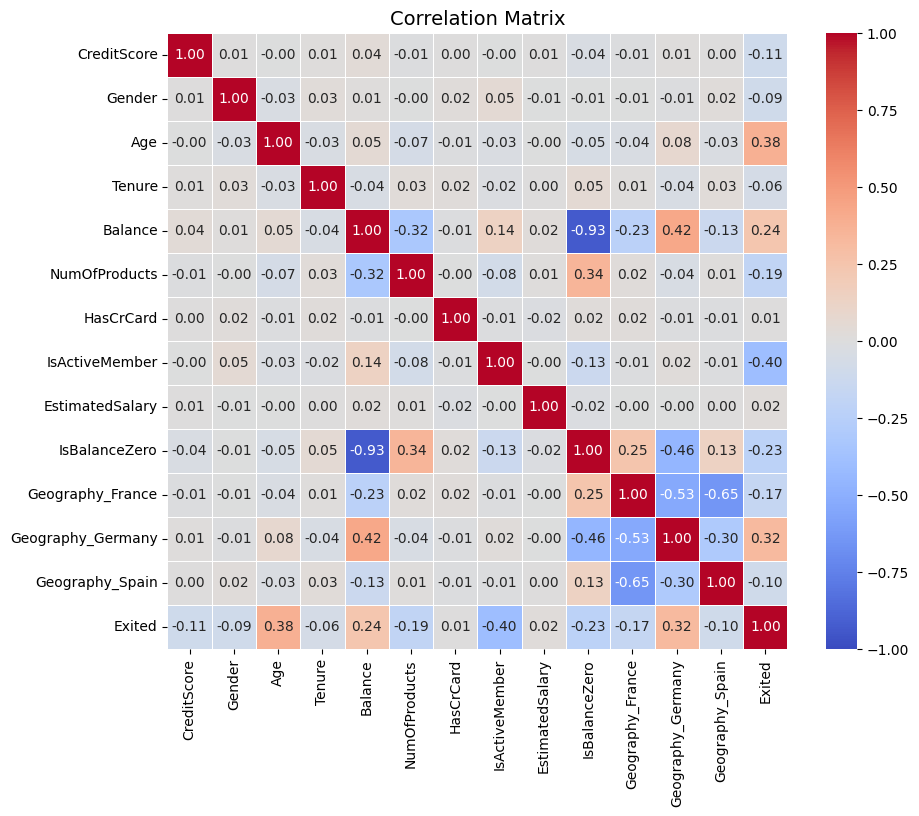

In [ ]:
corr_matrix = df_train.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,  fmt=".2f", cmap="coolwarm", vmin=-1,vmax=1, linewidths=0.5,cbar=True,  
)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

In [19]:
df_train.nunique()

CreditScore         456
Geography             3
Gender                2
Age                  69
Tenure               11
Balance            3825
NumOfProducts         4
HasCrCard             2
IsActiveMember        2
EstimatedSalary    7000
Exited                2
dtype: int64

In [20]:
df_train['Geography'].unique()
df_train['Geography'].value_counts()

Geography
France     3731
Spain      1871
Germany    1398
Name: count, dtype: int64

In [21]:
df_train['Exited'].value_counts()

Exited
0    5733
1    1267
Name: count, dtype: int64

In [22]:
df_train.groupby(df_train['Balance']==0)['Exited'].mean()

Balance
False    0.260460
True     0.085327
Name: Exited, dtype: float64

In [23]:
df_train.groupby('Geography')['Exited'].mean()

Geography
France     0.119807
Germany    0.427754
Spain      0.118653
Name: Exited, dtype: float64

In [24]:
df_train.groupby('Gender')['Exited'].mean()

Gender
Female    0.220986
Male      0.148379
Name: Exited, dtype: float64

In [25]:
df_train.groupby(df_train['EstimatedSalary']<50)['Exited'].mean()

EstimatedSalary
False    0.180883
True     1.000000
Name: Exited, dtype: float64

In [26]:
df_train.groupby(df_train['EstimatedSalary']<50)['Exited'].count()

EstimatedSalary
False    6999
True        1
Name: Exited, dtype: int64

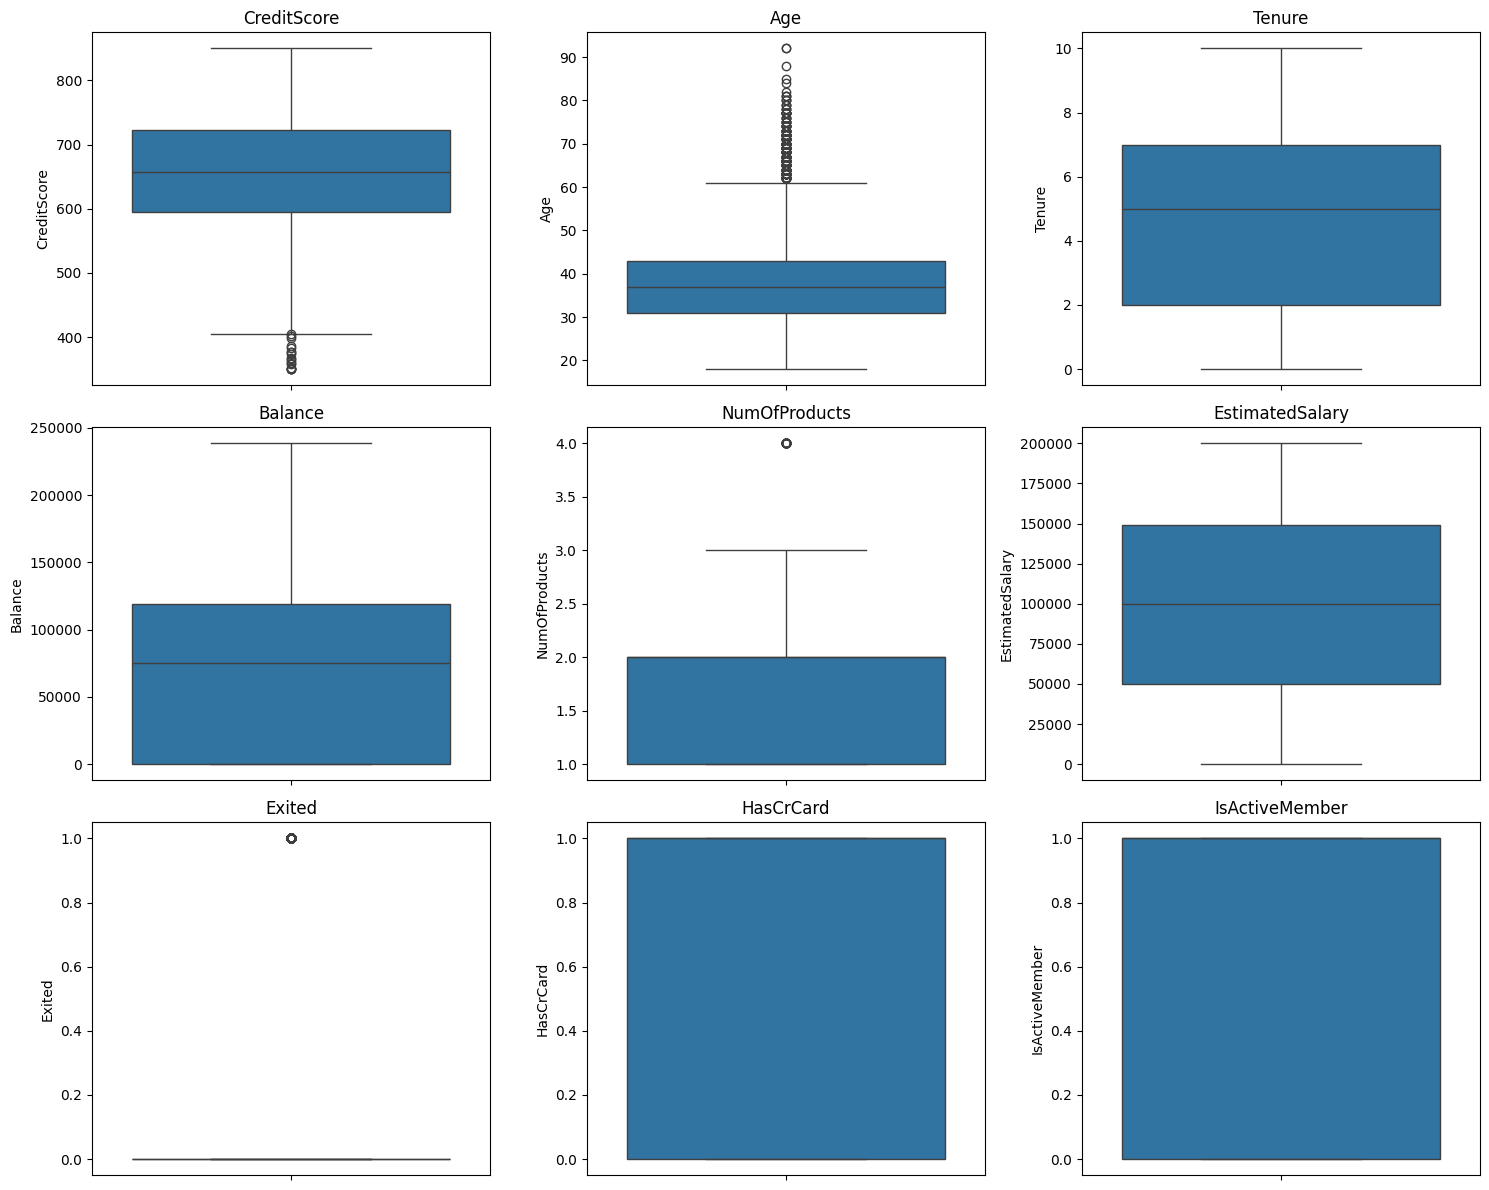

In [27]:
numerical_features = df_train[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary','Exited','HasCrCard','IsActiveMember']]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(y=df_train[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## **1.2 Feature Engineering**

In [28]:
df_train['IsBalanceZero'] = (df_train['Balance'] == 0).astype(int)
df_test['IsBalanceZero'] = (df_test['Balance'] == 0).astype(int)

In [29]:
df_train[['Balance','IsBalanceZero']].head(10)

,Balance,IsBalanceZero
0,0.00,1
1,123699.28,0
2,104129.24,0
3,123760.68,0
4,155393.98,0
5,155059.10,0
6,124495.98,0
7,87926.24,0
8,0.00,1
9,0.00,1


In [30]:
ohe = OneHotEncoder(sparse_output=False, drop=None, handle_unknown='ignore')
ohe.fit(df_train[['Geography']])

train_encoded = ohe.transform(df_train[['Geography']])
test_encoded = ohe.transform(df_test[['Geography']])

encoded_cols = ohe.get_feature_names_out(['Geography'])

df_train[encoded_cols] = train_encoded
df_test[encoded_cols] = test_encoded

df_train = df_train.drop('Geography', axis=1)
df_test = df_test.drop('Geography', axis=1)

In [31]:
df_test.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'IsBalanceZero',
       'Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype='object')

In [32]:
df_train.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
       'IsBalanceZero', 'Geography_France', 'Geography_Germany',
       'Geography_Spain'],
      dtype='object')

In [33]:
gender_map = {'Male': 1, 'Female': 0}

df_train['Gender'] = df_train['Gender'].map(gender_map)
df_test['Gender'] = df_test['Gender'].map(gender_map)

In [34]:
df_train['Gender'].unique()
df_train.head()
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        7000 non-null   int64  
 1   Gender             7000 non-null   int64  
 2   Age                7000 non-null   int64  
 3   Tenure             7000 non-null   int64  
 4   Balance            7000 non-null   float64
 5   NumOfProducts      7000 non-null   int64  
 6   HasCrCard          7000 non-null   int64  
 7   IsActiveMember     7000 non-null   int64  
 8   EstimatedSalary    7000 non-null   float64
 9   Exited             7000 non-null   int64  
 10  IsBalanceZero      7000 non-null   int64  
 11  Geography_France   7000 non-null   float64
 12  Geography_Germany  7000 non-null   float64
 13  Geography_Spain    7000 non-null   float64
dtypes: float64(5), int64(9)
memory usage: 765.8 KB


In [35]:
cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
scaler = StandardScaler()
scaler.fit(df_train[cols_to_scale])

df_train[cols_to_scale] = scaler.transform(df_train[cols_to_scale])
df_test[cols_to_scale] = scaler.transform(df_test[cols_to_scale])

In [36]:
df_train[cols_to_scale].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03
mean,-2.273737e-16,-1.400784e-16,9.744586e-17,-6.496391e-17,1.136868e-16,1.750980e-16
std,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00
min,-3.218089e+00,-1.985641e+00,-1.699435e+00,-1.022398e+00,-1.045741e+00,-1.729782e+00
25%,-6.462978e-01,-7.174664e-01,-1.005748e+00,-1.022398e+00,-1.045741e+00,-8.647536e-01
50%,4.522753e-03,-1.321550e-01,3.478347e-02,1.927527e-01,7.168854e-01,1.444088e-03
75%,6.868346e-01,4.531565e-01,7.284709e-01,8.988161e-01,7.168854e-01,8.620366e-01
max,2.030464e+00,5.233200e+00,1.769002e+00,2.817468e+00,4.242138e+00,1.739790e+00


In [37]:
cols = [c for c in df_train.columns if c != 'Exited'] + ['Exited']
df_train = df_train[cols]

In [38]:
df_train.to_csv('train_preprocessed.csv', index=False)
df_test.to_csv('test_preprocessed.csv', index=False)

In [39]:
df_train.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,IsBalanceZero,Geography_France,Geography_Germany,Geography_Spain,Exited
0,-0.037466,0,0.745812,0.034783,-1.022398,0.716885,1,0,-0.867576,1,1.0,0.0,0.0,0
1,0.224962,0,1.526227,-1.352591,0.970108,0.716885,0,1,0.095564,0,0.0,1.0,0.0,0
2,-0.110945,1,1.136020,-1.699435,0.654881,0.716885,1,0,1.424070,0,1.0,0.0,0.0,1
3,1.998973,1,2.696850,0.728471,0.971097,-1.045741,0,1,-0.807732,0,1.0,0.0,0.0,0
4,-0.730275,0,1.038468,0.728471,1.480636,0.716885,1,0,-1.499092,0,0.0,1.0,0.0,1


## **2 Handling The Classes Imablace**

# Spliting the dataset to training and validation set first 

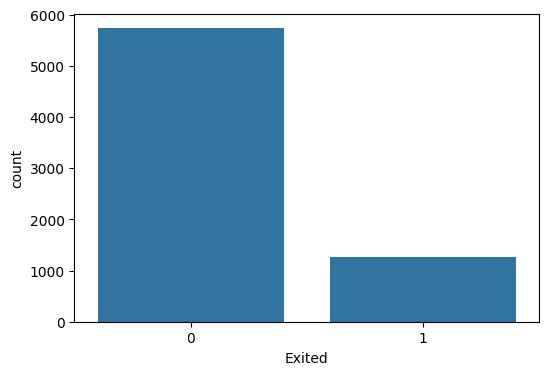

In [40]:
df_train['Exited'].value_counts()
# remove_records = 733 
# indices = df_train[df_train['Exited'] == 0].index 
# drop_indices = np.random.choice(indices, size=733, replace=False)

# df_train = df_train.drop(index=drop_indices)
# df_train['Exited'].value_counts()
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df_train)
plt.show()

# solving the imbalance on training set

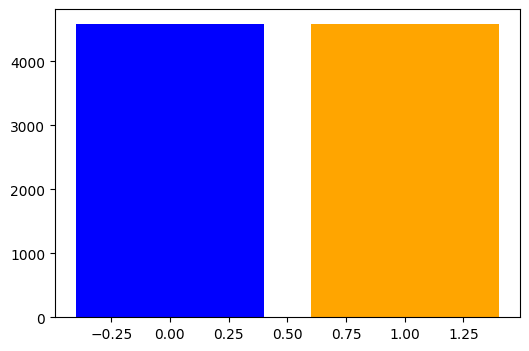

(array([0, 1]), array([4586, 4586]))

In [59]:
X = df_train.drop(columns=['Exited'])
y = df_train['Exited'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# we apply the adasyn/smote only on training set
adasyn = ADASYN(random_state=42) 
smote = SMOTE(random_state=42) 
X_train, y_train = smote.fit_resample(X_train, y_train)
cls, cnts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(6,4))
plt.bar(cls, cnts, color=['blue', 'orange'])
plt.show()
cls,cnts

## **3 Building The Network**

In [60]:
X_train = np.array(X_train) 
X_val = np.array(X_val)
# converting data train/val to pytorch ternsors
X_train_tensor = torch.tensor(X_train,dtype=torch.float32)
X_val_tensor = torch.tensor(X_val,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train,dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val,dtype=torch.float32).view(-1, 1)

In [61]:
class BankChurnDataset(Dataset):
    def __init__(self, features, labels):
        self.x = features
        self.y = labels

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [62]:
train_dataset = BankChurnDataset(X_train_tensor,y_train_tensor)
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)

val_dataset = BankChurnDataset(X_val_tensor,y_val_tensor)
val_loader = DataLoader(val_dataset,batch_size=32,shuffle=False)

In [63]:
class BankChurnClassifier(nn.Module):
    def __init__(self, input_size):
        super(BankChurnClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 16),
            nn.ReLU(),
            
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.net(x)
    
input_size = X_train.shape[1]

# MODEL:
model = BankChurnClassifier(input_size=input_size)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)
print(model)

BankChurnClassifier(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
    (11): Sigmoid()
  )
)


In [64]:
def train_model(model,train_loader,val_loader,optimizer,criterion,epochs=50):

    train_loss_history = []
    val_loss_history = []
    train_accuracy_history = []
    val_accuracy_history = []

    for epoch in range(epochs):

        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_X, batch_Y in train_loader:

            batch_X = batch_X
            batch_Y = batch_Y

            # 1. Zero gradients
            optimizer.zero_grad()

            # 2. Forward Pass
            predictions = model(batch_X)

            # 3. Loss
            loss = criterion(predictions, batch_Y)

            # 4. Backward Pass
            loss.backward()

            # 5. Update weights
            optimizer.step()

            train_loss += loss.item()

            # Calculate Training Accuracy
            predicted_classes = (
                predictions >= 0.5
            ).float()

            train_correct += (
                predicted_classes == batch_Y
            ).sum().item()

            train_total += batch_Y.size(0)


        # Average Training Loss
        train_loss = train_loss / len(train_loader)

        # Training Accuracy
        train_accuracy = train_correct / train_total

        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for batch_X, batch_Y in val_loader:

                batch_X = batch_X
                batch_Y = batch_Y

                predictions = model(batch_X)

                loss = criterion(
                    predictions,
                    batch_Y
                )

                val_loss += loss.item()

                # Calculate Validation Accuracy
                predicted_classes = (
                    predictions >= 0.5
                ).float()

                val_correct += (
                    predicted_classes == batch_Y
                ).sum().item()

                val_total += batch_Y.size(0)

        val_loss = val_loss / len(val_loader)

        val_accuracy = val_correct / val_total

        train_loss_history.append(
            train_loss
        )

        val_loss_history.append(
            val_loss
        )

        train_accuracy_history.append(
            train_accuracy
        )

        val_accuracy_history.append(
            val_accuracy
        )
        if epoch %10 == 0:
            print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )


    return (
        train_loss_history,
        val_loss_history,
        train_accuracy_history,
        val_accuracy_history
    )

In [65]:
train_losses, val_losses, train_acc, val_acc = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=50
)

Epoch [1/50] Train Loss: 0.3497 | Train Acc: 0.8618 | Val Loss: 0.1505 | Val Acc: 0.9450
Epoch [11/50] Train Loss: 0.1221 | Train Acc: 0.9524 | Val Loss: 0.0779 | Val Acc: 0.9700
Epoch [21/50] Train Loss: 0.1092 | Train Acc: 0.9563 | Val Loss: 0.0720 | Val Acc: 0.9679
Epoch [31/50] Train Loss: 0.1001 | Train Acc: 0.9618 | Val Loss: 0.0747 | Val Acc: 0.9714
Epoch [41/50] Train Loss: 0.0946 | Train Acc: 0.9642 | Val Loss: 0.0817 | Val Acc: 0.9686


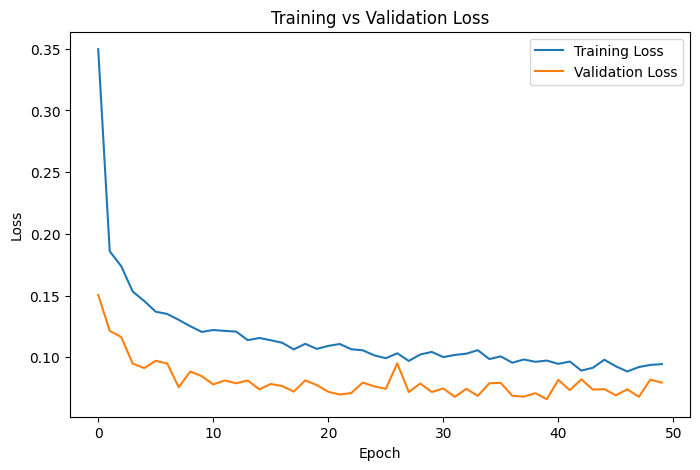

In [66]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

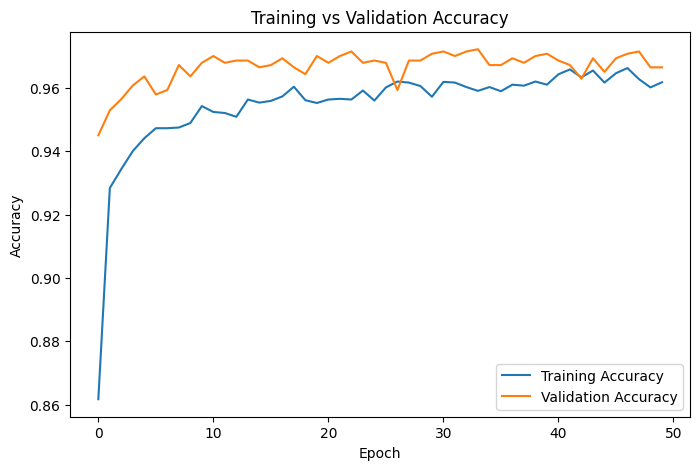

In [67]:
plt.figure(figsize=(8, 5))

plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

In [79]:
def evaluate_and_plot(y_true, probs, set_name="Dataset"):
    """Evaluate model performance and find optimal threshold."""
    
    # Find best threshold by accuracy
    thresholds = np.linspace(0.1, 0.9, 81)
    accuracies = [accuracy_score(y_true, (probs >= t).astype(int)) for t in thresholds]
    best_threshold = thresholds[np.argmax(accuracies)]
    
    predictions = (probs >= best_threshold).astype(int)

    print(f"Best threshold: {best_threshold:.3f}")
    print(f"ROC-AUC: {roc_auc_score(y_true, probs):.4f}")
    print(f"acc: {accuracy_score(y_true, predictions):.4f}")
    print(f"precision: {precision_score(y_true, predictions):.4f}")
    print(f"Recall: {recall_score(y_true, predictions):.4f}")
    print(f"F1-Score: {f1_score(y_true, predictions):.4f}\n")
    
    plt.figure(figsize=(6, 4))
    cm = confusion_matrix(y_true, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Exited', 'Exited'],
                yticklabels=['Not Exited', 'Exited'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{set_name} - Threshold: {best_threshold:.3f}')
    plt.tight_layout()
    plt.show()
    
    return best_threshold, predictions

In [80]:
model.eval()
with torch.no_grad():
    train_probs = model(X_train_tensor).flatten().cpu().numpy()
    val_probs = model(X_val_tensor).flatten().cpu().numpy()

Best threshold: 0.550
ROC-AUC: 0.9984
acc: 0.9802
precision: 0.9729
Recall: 0.9878
F1-Score: 0.9803



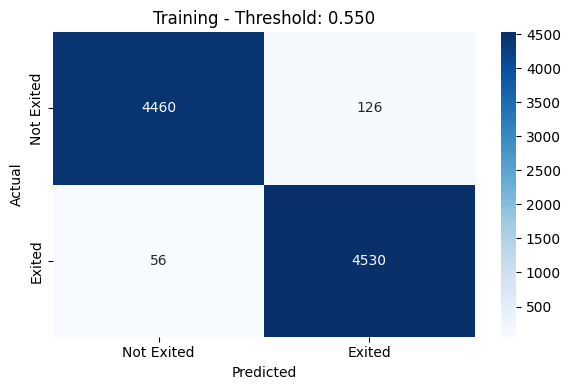

In [81]:
# Evaluate Training Set
best_thresh_train, train_preds = evaluate_and_plot(
    y_train, train_probs, set_name="Training"
)

Best threshold: 0.770
ROC-AUC: 0.9958
acc: 0.9736
precision: 0.9426
Recall: 0.9091
F1-Score: 0.9256



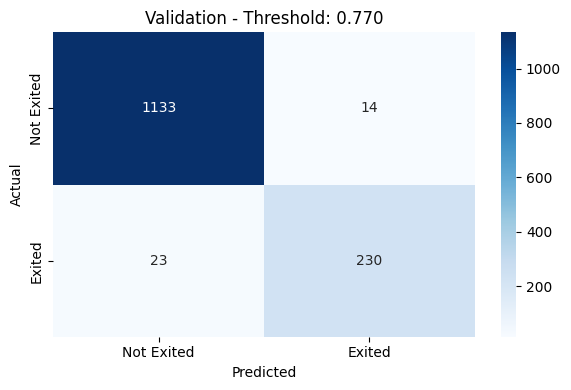

In [82]:
# Evaluate Validation Set
best_thresh_val, val_preds = evaluate_and_plot(
    y_val, val_probs, set_name="Validation"
)

## **Prediction The Testset**

In [83]:
# test set is scaled previously 
df_test = np.array(df_test)
x_test_tensor = torch.tensor(df_test, dtype=torch.float32) 
test_best_thres = (best_thresh_train + best_thresh_val)/2

model.eval()
with torch.no_grad():
    test_probs = model(x_test_tensor).flatten().cpu().numpy()
    y_test_preds = (test_probs < test_best_thres).astype(int)

print(test_best_thres)

0.66


In [84]:
ids = range(len(y_test_preds)) 
submit = pd.DataFrame(
    {
        'id': ids,
        'Exited': y_test_preds.flatten()
    }
)
submit.to_csv('sample4.csv', index=False)